In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [11]:
# ==========================================
# 1. Load Dataset
# ==========================================
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Select 3 classes (T-shirt=0, Sneaker=7, Bag=8)
selected_classes = [0, 7, 8]

def filter_classes(x, y, classes):
    mask = np.isin(y, classes)
    return x[mask], y[mask]

x_train, y_train = filter_classes(x_train, y_train, selected_classes)
x_test, y_test = filter_classes(x_test, y_test, selected_classes)

In [12]:
# Remap labels to 0,1,2
label_map = {0:0, 7:1, 8:2}
y_train = np.array([label_map[i] for i in y_train])
y_test = np.array([label_map[i] for i in y_test])

In [13]:
# ==========================================
# 2. Data Split (Train → Train + Validation)
# ==========================================
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

In [14]:
# ==========================================
# 3. OpenCV Augmentation Function
# ==========================================
def augment_image(img):
    if random.random() > 0.5:
        img = cv2.flip(img, 1)

    if random.random() > 0.5:
        angle = random.randint(-25, 25)
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
        img = cv2.warpAffine(img, M, (w, h))

    if random.random() > 0.5:
        value = random.randint(-40, 40)
        img = cv2.convertScaleAbs(img, alpha=1, beta=value)

    return img

In [15]:
# ==========================================
# 4. Preprocessing Function (OpenCV)
# ==========================================
IMG_SIZE = 64

def preprocess_images(images, augment=False):
    processed = []

    for img in images:
        # Resize
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Convert grayscale → RGB
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        # Apply augmentation only if required
        if augment:
            img = augment_image(img)

        # Normalize
        img = img / 255.0

        processed.append(img)

    return np.array(processed)

In [16]:
# Apply preprocessing
x_train = preprocess_images(x_train, augment=True)
x_val = preprocess_images(x_val, augment=False)
x_test = preprocess_images(x_test, augment=False)

In [17]:
# One-hot encoding
y_train = to_categorical(y_train, 3)
y_val = to_categorical(y_val, 3)
y_test = to_categorical(y_test, 3)

In [18]:
# ==========================================
# 5. CNN Model
# ==========================================
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(3, activation='softmax')
])

In [19]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,587 (2.61 MB)

 Trainable params: 683,587 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# ==========================================
# 6. Train Model
# ==========================================
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=32
)


Epoch 1/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 120s 262ms/step - accuracy: 0.9510 - loss: 0.1445 - val_accuracy: 0.9836 - val_loss: 0.0511
Epoch 2/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 137s 251ms/step - accuracy: 0.9785 - loss: 0.0686 - val_accuracy: 0.9908 - val_loss: 0.0365
Epoch 3/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 110s 244ms/step - accuracy: 0.9828 - loss: 0.0525 - val_accuracy: 0.9903 - val_loss: 0.0345
Epoch 4/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 145s 252ms/step - accuracy: 0.9855 - loss: 0.0429 - val_accuracy: 0.9906 - val_loss: 0.0307
Epoch 5/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 111s 247ms/step - accuracy: 0.9882 - loss: 0.0319 - val_accuracy: 0.9925 - val_loss: 0.0312
Epoch 6/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 143s 249ms/step - accuracy: 0.9912 - loss: 0.0277 - val_accuracy: 0.9856 - val_loss: 0.0435
Epoch 7/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 119s 263ms/step - accuracy: 0.9903 - loss: 0.0268 - val_accuracy: 0.9922 - val_loss: 0.0336
Epoch 8/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 115s 255ms/step - accuracy: 0.9943 -

In [22]:
# ==========================================
# 7. Evaluate Model
# ==========================================
loss, acc = model.evaluate(x_test, y_test)
print(f"\n✅ Test Accuracy: {acc:.4f}")

# Predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)


94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.9880 - loss: 0.0424

✅ Test Accuracy: 0.9880
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step


In [23]:
# ==========================================
# 8. Confusion Matrix
# ==========================================
cm = confusion_matrix(y_true, y_pred_classes)

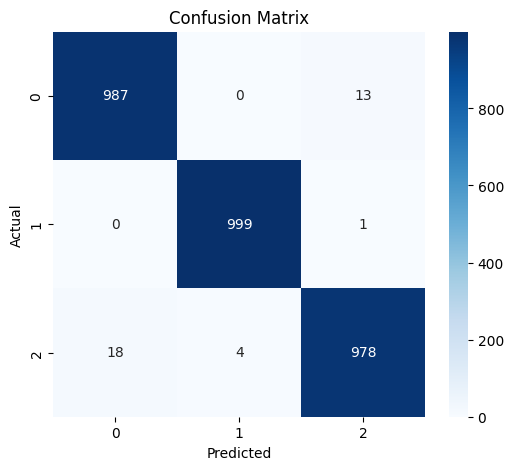

In [24]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
# ==========================================
# 9. Precision, Recall, F1-score
# ==========================================
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes))



Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1000
           1       1.00      1.00      1.00      1000
           2       0.99      0.98      0.98      1000

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



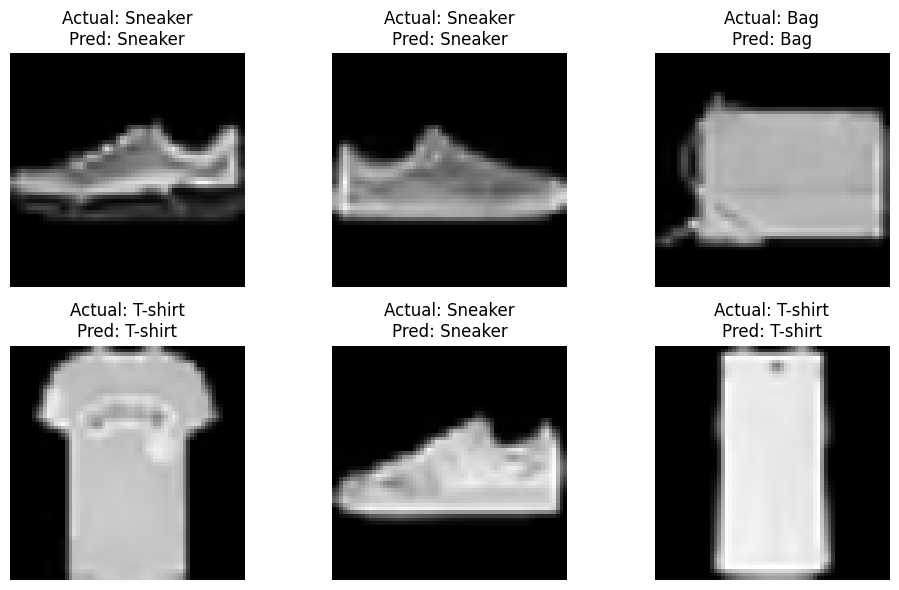

In [27]:
# ==========================================
# 10. Display Predictions
# ==========================================
labels = ["T-shirt", "Sneaker", "Bag"]

plt.figure(figsize=(10,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(x_test[i])
    plt.title(f"Actual: {labels[y_true[i]]}\nPred: {labels[y_pred_classes[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()
